In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [9]:
##Load Dataset
df=pd.read_csv("medical dataset.csv")
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [10]:
#data understanding
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [11]:
df.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [12]:
#Encode Categorical Variables
result_map = {
    "positive": 1,
    "negative": 0
    
}

df["Result"] = df["Result"].map(result_map)
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


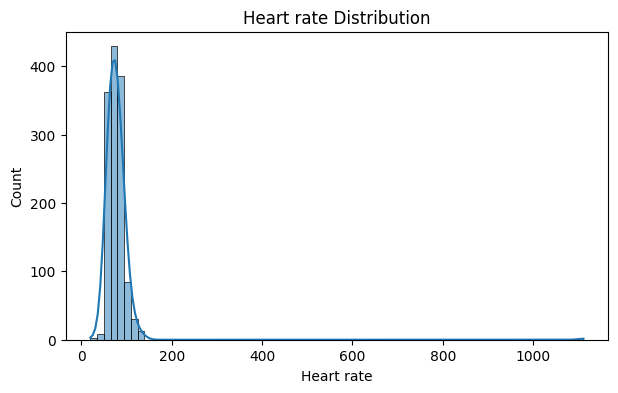

In [16]:
##EDA
###UNIVARIATE ANALYSIS
####price Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["Heart rate"], kde=True)
plt.title("Heart rate Distribution")
plt.show()

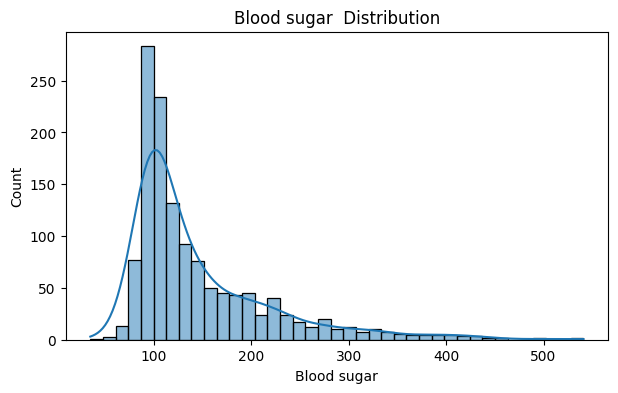

In [17]:
##EDA
###UNIVARIATE ANALYSIS
####price Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["Blood sugar"], kde=True)
plt.title("Blood sugar  Distribution")
plt.show()

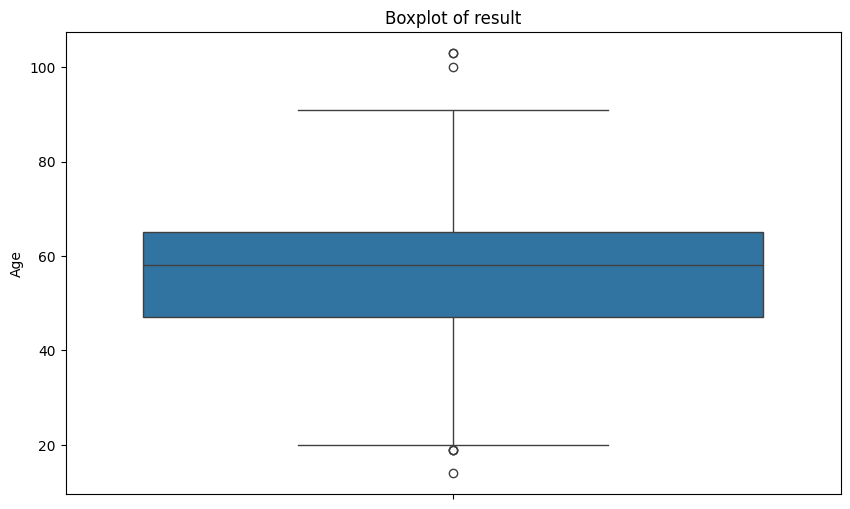

In [19]:
##Boxplot – Salary
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Age'])
plt.title("Boxplot of result")
plt.show()

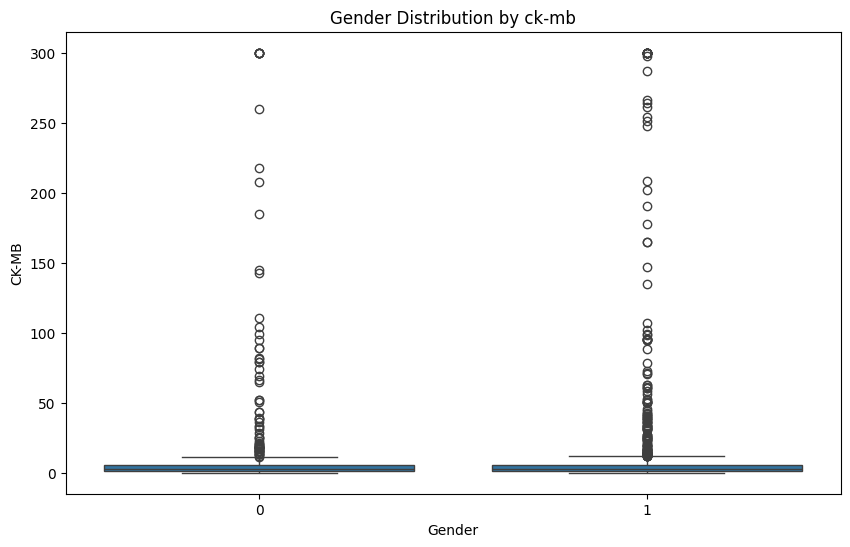

In [25]:
###Bedrooms Distribution by floors
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='CK-MB', data=df)
plt.title("Gender Distribution by ck-mb")
plt.show()

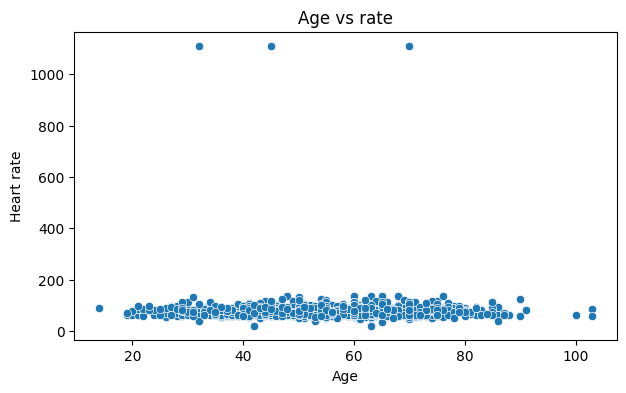

In [28]:
##BIVARIATE ANALYSIS
###Age vs Salary
plt.figure(figsize=(7,4))
sns.scatterplot(x='Age', y='Heart rate', data=df)
plt.title("Age vs rate")
plt.show()

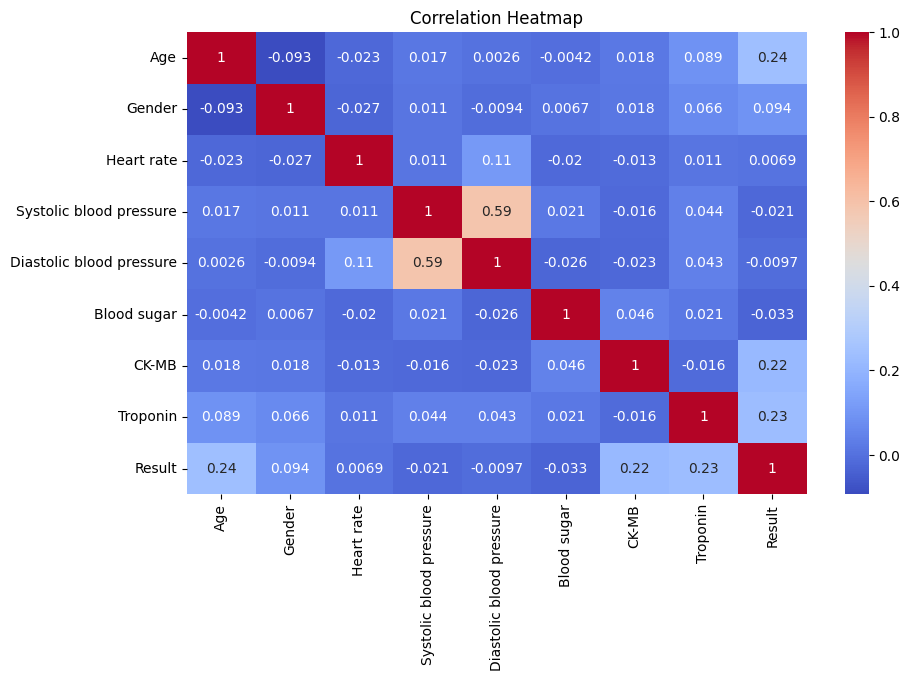

In [29]:
####MULTIVARIATE ANALYSIS
###Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

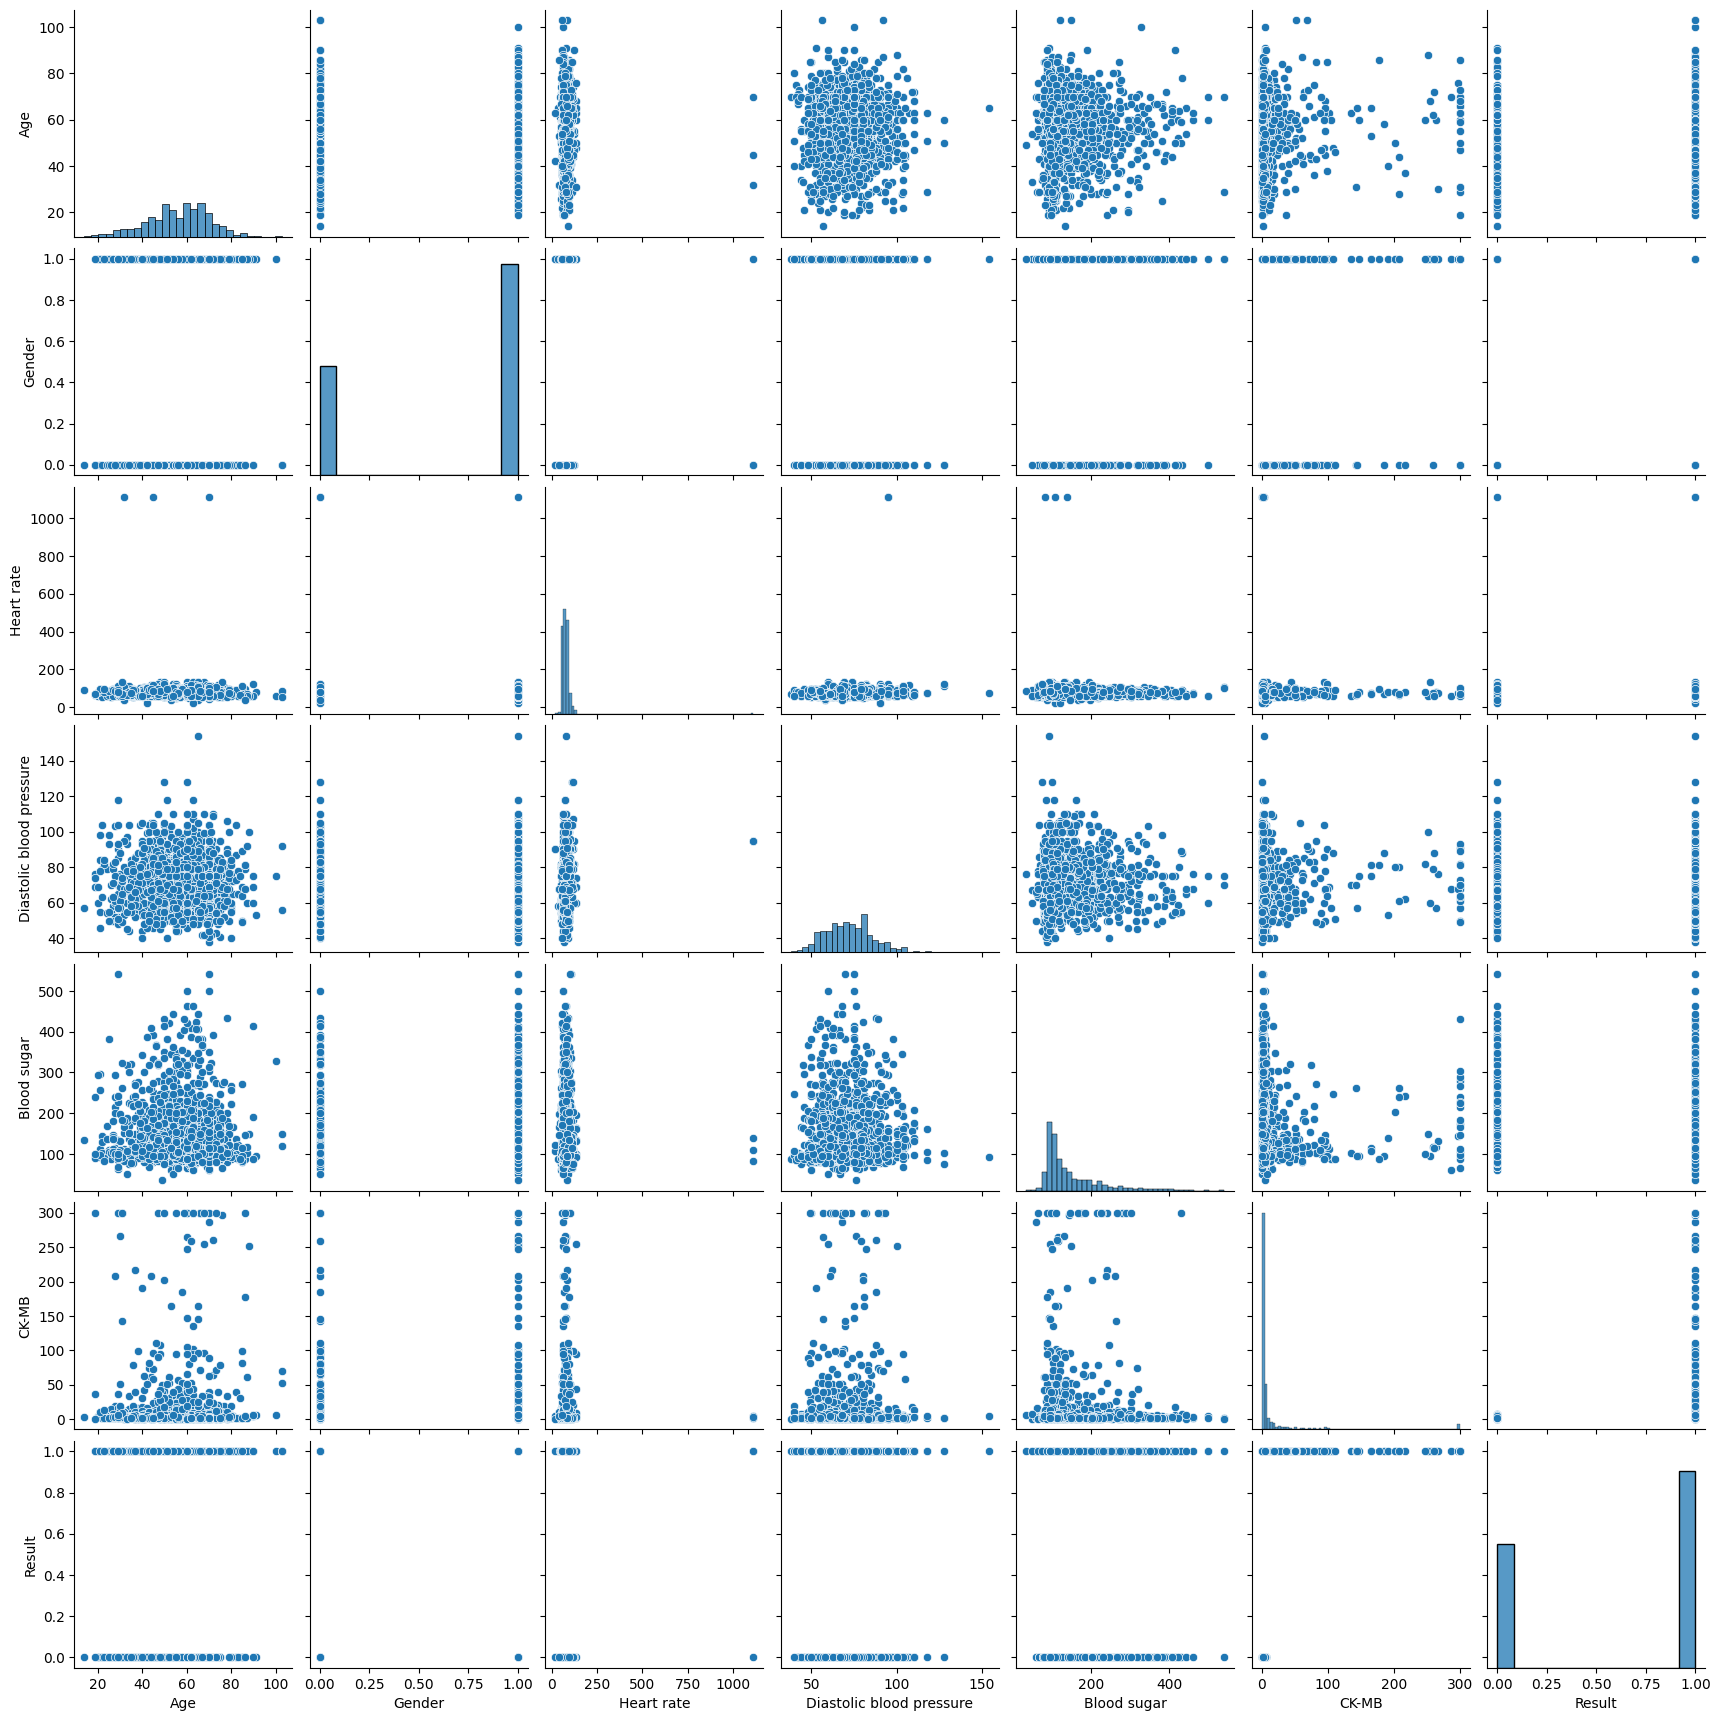

In [31]:
##Pair Plot
sns.pairplot(df[['Age','Gender','Heart rate','Diastolic blood pressure','Blood sugar','CK-MB','Result'
                ]])
plt.show()

In [32]:
X = df[['Heart rate', 'Diastolic blood pressure', 'Blood sugar']]
y = df['Result']

In [33]:
le = LabelEncoder()
y = le.fit_transform(y)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [35]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
y_pred = knn.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)

In [39]:
print("Predicted:", y_pred)
print("Accuracy:", accuracy)

Predicted: [0 1 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0
 0 1 0 1 1 1 1 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 0 0 1 0 1
 0 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 1 0 1 1 1
 0 1 1 0 0 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0
 1 0 1 1 0 0 1 0 0 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 1 0 1 0 1 0 0 1 1 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0
 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 1 1
 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 0
 0 1 1 0 0 1 0 1 0 0 0 1 1 1 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1]
Accuracy: 0.5333333333333333
